In [43]:
##### Cellule 2.1 #####

# Chargement du gestionnaire de paquets Julia.
using Pkg

# Bibliothèques de manipulation de données
using DataFrames, CSV, Dates

# Bibliothèques de calcul statistique et algébrique
using Statistics, LinearAlgebra

#Bibliothèques d'optimisation :
  # JuMP pour la modélisation
  # Gurobi pour la résolution numérique
   using JuMP, Gurobi

#Bibliothèque de visualisation graphique
using Plots

#Bibliothèque de formatage de texte
using Printf

#Dossier de sortie pour les figures, tableaux et exports du chapitre 2
OUTDIR = "outputs_chap2_sec2_4"
isdir(OUTDIR) || mkpath(OUTDIR)

 #Liste des actifs étudiés (identique au chapitre 1)
TICKERS = ["AAPL", "MSFT", "AMZN", "GOOG", "META"]

# Nombre total d'actifs
N= length(TICKERS)

 # Capital initial, utilisé pour l'interprétation économique
 #des résultats en termes de richesse
  W0= 1_000_000.0

 #Nombre usuel de jours de bourse par an,
#utilisé pour annualiser certaines quantités si nécessaire
FREQ= 252

 #Niveau de confiance de la CVaR
#Ici α = 0.95 signifie que l’on s’intéresse aux 5% pires pertes
  α= 0.95

 # Indicateur logique pour activer ou non l’export des résultats
#vers des fichiers externes
EXPORT = true

true

In [45]:
#### Cellule 2.2 #########

# Nom du fichier contenant les prix historiques
PRICE_FILE = "prices_tech.csv"

# Vérification que le fichier existe
    @assert isfile(PRICE_FILE) "Fichier introuvable: $PRICE_FILE"

#Lecture du fichier CSV
prices= CSV.read(PRICE_FILE, DataFrame)

  #Vérification de la présence de la colonne Date
    @assert "Date" in names(prices) "La colonne 'Date' est absente. Colonnes dispo: $(names(prices))"

#Conversion de la colonne Date si nécessaire
if !(eltype(prices.Date) <: Date)
    prices.Date = Date.(prices.Date)
end

    #Conservation des colonnes utiles : Date + actifs
   select!(prices, ["Date"; TICKERS]...)

# Tri des données par ordre chronologique
   sort!(prices, :Date)

 #Affichage d’un aperçu
   println("Aperçu des prix :")
   println(first(prices, 3))
   println(last(prices, 3))

Aperçu des prix :
3×6 DataFrame
 Row │ Date        AAPL     MSFT     AMZN     GOOG     META    
     │ Date        Float64  Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2015-01-02  24.2374  40.1536  15.426   26.2405    78.45
   2 │ 2015-01-05  23.5555  39.7826  15.1095  25.6935    77.19
   3 │ 2015-01-06  23.5575  39.1972  14.7645  25.098     76.15
3×6 DataFrame
 Row │ Date        AAPL     MSFT     AMZN     GOOG     META    
     │ Date        Float64  Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2025-12-29   273.76   487.1    232.07   314.39   658.69
   2 │ 2025-12-30   273.08   487.48   232.53   314.55   665.95
   3 │ 2025-12-31   271.86   483.62   230.82   313.8    660.09


In [47]:
###### Cellule 2.3 ##########

 #Vérification de l'absence de valeurs manquantes pour chaque actif
for tk in TICKERS
    miss = count(ismissing, prices[!, tk])
    @assert miss == 0 "Valeurs manquantes détectées dans $tk : $miss"
end

  #Vérification de la positivité des prix
 #(les prix d'actifs doivent être strictement positifs)
for tk in TICKERS
    @assert minimum(prices[!, tk]) > 0 "Prix non positifs détectés dans $tk"
end

# Message de confirmation
println("Contrôles des prix OK. Nombre d'observations : ", nrow(prices))

Contrôles des prix OK. Nombre d'observations : 2766


In [49]:
########### Cellule 2.4 ###########

  #Fonction de calcul des rendements simples :
  #R[t] = P[t] / P[t-1] - 1
simple_returns(p::AbstractVector{<:Real}) =
    p[2:end] ./ p[1:end-1] .- 1.0

  # Fonction de calcul des log-rendements :
  #r[t] = log(P[t] / P[t-1])
 
     log_returns(p::AbstractVector{<:Real}) =
    log.(p[2:end] ./ p[1:end-1])

log_returns (generic function with 1 method)

In [53]:
####### Cellule 2.5 ########

# Nombre d'observations temporelles
   T= nrow(prices)

 #Initialisation des matrices de rendements :
 #dimensions : (T-1) x N car on perd une observation
   R_simple = Matrix{Float64}(undef, T-1, N)
   R_log = Matrix{Float64}(undef, T-1, N)

#Calcul des rendements pour chaque actif
for (j, tk) in enumerate(TICKERS)
    p = Float64.(prices[!, tk])
    R_simple[:, j] = simple_returns(p)
    R_log[:, j] = log_returns(p)
end

#Dates associées aux rendements
  dates_ret= prices.Date[2:end]

#Affichage des dimensions
  println("Dimensions des rendements :")
  println("R_simple : ", size(R_simple))
  println("R_log    : ", size(R_log))

Dimensions des rendements :
R_simple : (2765, 5)
R_log    : (2765, 5)


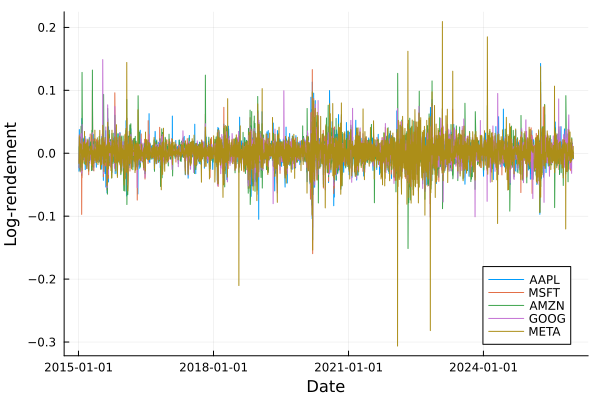

In [55]:
#### Cellule 2.6 #######

   #Création d’un graphique des log-rendements
  #pour vérifier visuellement la dynamique des actifs
p_ctrl = plot(dates_ret, R_log[:, 1],
    label=TICKERS[1],
    xlabel="Date",
    ylabel="Log-rendement",
    linewidth=1
)

    #Ajout des autres actifs au graphique
for j in 2:N
    plot!(p_ctrl, dates_ret, R_log[:, j],
          label=TICKERS[j],
          linewidth=1)
end

#Sauvegarde de la figure
savefig(p_ctrl, joinpath(OUTDIR, "chap2_sec2_4_control_log_returns.png"))

#Affichage
p_ctrl

In [59]:
######## Cellule 2.7 ########

  #Construction des scénarios historiques pour la CVaR
  #Chaque observation temporelle (date) est considérée comme un scénario

     #Utilisation des log-rendements (choix standard en finance)
     #Transposition pour obtenir une matrice de dimension :
     #N x M (actifs x scénarios)
        R= copy(R_log)'  

  #Nombre total de scénarios
    M= size(R, 2)

# Affichage des dimensions
println("Scénarios (historiques) :")
println("Dimension de R = ", size(R))
println("Nombre de scénarios M = ", M)

Scénarios (historiques) :
Dimension de R = (5, 2765)
Nombre de scénarios M = 2765


In [61]:
####### Cellule 2.8 ######

# Estimation de la moyenne des rendements (μ)

#Moyenne empirique journalière des log-rendements
    #R_log est de dimension (T-1) x N, donc on prend la moyenne sur les lignes
μ_daily = vec(mean(R_log, dims=1))

# Annualisation des rendements moyens
μ_ann = μ_daily .* FREQ

# Affichage des résultats
println("μ_daily (aperçu) :")
println(μ_daily)

println("μ_ann (aperçu) :")
println(μ_ann)

μ_daily (aperçu) :
[0.0008742822181500567, 0.0009000316000883666, 0.0009785113159061316, 0.0008974509300276831, 0.0007703127342427186]
μ_ann (aperçu) :
[0.2203191189738143, 0.2268079632222684, 0.24658485160834517, 0.22615763436697614, 0.1941188090291651]


In [65]:
####### Cellule 2.9 ########

    #Fonction de résolution du problème CVaR–SAA pénalisé :
   
     # Entrées :
       # R : matrice N x M des scénarios de rendements
       # μ_ann : vecteur des rendements moyens annualisés
       # η : paramètre de pénalisation du risque
       # α : niveau de confiance de la CVaR
#
     # Sorties :
       # poids optimaux
       # valeur de la fonction objectif
       # rendement espéré annualisé
       # VaR journalière
       # CVaR journalière
       # CVaR annualisée (approximation)
       # statut du solveur
function solve_cvar_penalized(
    R::AbstractMatrix{<:Real},
    μ_ann::Vector{Float64},
    η::Float64;
    α::Float64=0.95,
    silent::Bool=true,
    FREQ::Int=252
)

     #Conversion de sécurité en matrice Float64
    R = Matrix{Float64}(R)

     #Dimensions :
       #N= nombre d'actifs
       #M= nombre de scénarios
    N, M = size(R)

    #Création du modèle d'optimisation
    
      model= Model(Gurobi.Optimizer)
    if silent
        set_silent(model)
    end

    #Variables de décision : poids du portefeuille
       @variable(model, x[1:N] >= 0.0)

     #Contrainte budgétaire
      @constraint(model, sum(x) == 1.0)

       #Variables auxiliaires de Rockafellar–Uryasev :
       #t : proxy de la VaR
       #z[m] : excès de perte au-delà de t dans le scénario m
          @variable(model, t)
          @variable(model, z[1:M] >= 0.0)

    #Pour chaque scénario m, la perte est :
    #L_m = - x' r^(m)
    #et on impose :
    #z_m >= L_m - t
    for m in 1:M
        @constraint(model, z[m] >= -sum(R[i, m] * x[i] for i in 1:N) - t)
    end

    #Définition de la CVaR empirique (échelle journalière)
      CVaR= t + (1.0 / ((1.0 - α) * M)) *sum(z)

      #Rendement espéré annualisé du portefeuille
      ER_ann= sum(μ_ann[i] * x[i] for i in 1:N)

      #Annualisation approximative de la CVaR
      CVaR_ann= CVaR * FREQ

      #Fonction objectif pénalisée :
     #compromis entre risque extrême (CVaR) et rendement
    @objective(model, Min, η* CVaR_ann - ER_ann)

     #Résolution
    optimize!(model)

    #Vérification du statut du solveur
    status = termination_status(model)
    if status != OPTIMAL
        error("Optimization failed with status: $status")
    end

    #Extraction de la solution optimale
    xopt= value.(x)
     obj= objective_value(model)
    tval = value(t)
    cval= value(CVaR)

    # Annualisation approximative de la CVaR
    cvar_ann= value(CVaR_ann)

    return xopt, obj, dot(μ_ann, xopt), tval, cval, cvar_ann, status
end

solve_cvar_penalized (generic function with 2 methods)

In [69]:
###### Cellule 2.10 ##########

# Définition de l’intervalle du paramètre de pénalisation η
  η_min = 1e-2
  η_max= 1e2

#Nombre de points dans la grille (approximation quasi continue)
 K= 200

 #Construction d’une grille logarithmique :
 #permet d’explorer efficacement différentes échelles de risque
    u= range(log10(η_min), log10(η_max), length=K)
    η_grid = 10 .^ collect(u)

# Affichage des informations principales
 println("Grille η :")
 println("η_min = ", first(η_grid))
 println("η_max = ", last(η_grid))
 println("Nombre de points = ", length(η_grid))

Grille η :
η_min = 0.010000000000000002
η_max = 100.0
Nombre de points = 200


In [71]:
#### Cellule 2.11 #######

 #S'assurer que R est bien une matrice Float64
 #(évite les problèmes liés au type Adjoint après transposition)
  R= Matrix(R)

# Initialisation du tableau des résultats CVaR
results_cvar = DataFrame(
    η = Float64[],       # paramètre de pénalisation
    log10η = Float64[],   # version logarithmique
    ER_ann = Float64[],   # rendement espéré annualisé
    VaR_daily = Float64[],  # VaR journalière
    CVaR_daily = Float64[], # CVaR journalière
    CVaR_ann = Float64[],   # CVaR annualisée
    Obj= Float64[]     # valeur de la fonction objectif
)

  #Matrice des poids optimaux
  #Dimensions : K (nombre de η) x N (actifs)
    X_cvar = Matrix{Float64}(undef, K, N)

#Boucle sur la grille de η
for (k, η) in enumerate(η_grid)

    #Résolution du problème CVaR–SAA
    xopt, obj, er_ann, var_daily, cvar_daily, cvar_ann, status =
        solve_cvar_penalized(R, μ_ann, η; α=α, silent=true, FREQ=FREQ)

      #Stockage des poids optimaux
    X_cvar[k, :] = xopt
     #Ajout des résultats dans la table
    push!(results_cvar,
        (η, log10(η), er_ann, var_daily, cvar_daily, cvar_ann, obj)
    )
end

# Aperçu des résultats
println("Aperçu des résultats CVaR :")
println(first(results_cvar, 5))

Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic lic

In [73]:
######## Cellule 2.12 ########

#Portefeuille équipondéré (benchmark)
  xEW= fill(1.0/N, N)

 #Rendement espéré annualisé
ER_EW_ann = dot(μ_ann, xEW)

# Fonction de calcul empirique de la CVaR à partir des scénarios
function empirical_cvar_from_scenarios(R::Matrix{Float64}, x::Vector{Float64}; α::Float64=0.95)

    #Calcul des pertes journalières : L_m = -x' r^(m)
     losses = [-dot(x, R[:, m]) for m in 1:size(R, 2)]

    #Tri croissant des pertes
     sort!(losses)

    # Indice correspondant au quantile α
    k= min(ceil(Int, α * length(losses)), length(losses))

    #CVaR = moyenne des pertes au-delà du quantile α
    return mean(losses[k:end])
end

# Calcul de la CVaR du portefeuille équipondéré
CVaR_EW_daily = empirical_cvar_from_scenarios(R, xEW; α=α)

# Annualisation de la CVaR
CVaR_EW_ann = CVaR_EW_daily * FREQ

# Affichage des résultats
println("Baseline équipondéré :")
println("ER_ann = ", ER_EW_ann)
println("CVaR_daily = ", CVaR_EW_daily)
println("CVaR_ann = ", CVaR_EW_ann)

Baseline équipondéré :
ER_ann = 0.22279767544011383
CVaR_daily = 0.039258129881371624
CVaR_ann = 9.89304873010565


In [75]:
##### Cellule 2.13 #######

#Calcul de la richesse attendue à horizon 1 an
#en utilisant les log-rendements annualisés

  #Pour les portefeuilles optimisés :
  #W1 ≈ W0 * exp(ER_ann)
    results_cvar.EW1 = W0 .* exp.(results_cvar.ER_ann)

#Pour le portefeuille équipondéré (benchmark)
EW1_EW = W0 * exp(ER_EW_ann)

# Affichage
println("Richesse attendue (benchmark équipondéré) : ", EW1_EW)

Richesse attendue (benchmark équipondéré) : 1.2495677299175858e6


In [77]:
#### Cellule 2.14 ########

# Valeurs représentatives du paramètre η pour résumer les résultats
η_show = [1e-2, 5e-2, 1e-1, 5e-1, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]

# Fonction d'extraction d’un tableau synthétique à partir des résultats CVaR
function extract_table_cvar(results::DataFrame, η_show::Vector{Float64})

    # Initialisation du DataFrame de sortie
    df = DataFrame()
    df.η = η_show
    df.log10η = log10.(η_show)
    df.ER_ann = similar(η_show)
    df.CVaR_ann = similar(η_show)
    df.EW1 = similar(η_show)

    # Pour chaque valeur de η, on récupère la ligne la plus proche
    for (i, η) in enumerate(η_show)
        idx = argmin(abs.(results.η .- η))
        df.ER_ann[i]   = results.ER_ann[idx]
        df.CVaR_ann[i] = results.CVaR_ann[idx]
        df.EW1[i]      = results.EW1[idx]
    end

    return df
end

# Construction du tableau synthétique
tab_cvar = extract_table_cvar(results_cvar, η_show)

# Affichage
tab_cvar

Row,η,log10η,ER_ann,CVaR_ann,EW1
,Float64,Float64,Float64,Float64,Float64
1,0.01,-2.0,0.246585,11.9546,1.27965e6
2,0.05,-1.30103,0.246585,11.9546,1.27965e6
3,0.1,-1.0,0.246585,11.9546,1.27965e6
4,0.5,-0.30103,0.246585,11.9546,1.27965e6
5,1.0,0.0,0.246585,11.9546,1.27965e6
6,2.0,0.30103,0.236889,10.0915,1.2673e6
7,5.0,0.69897,0.228125,9.26087,1.25624e6
8,10.0,1.0,0.227287,9.23231,1.25519e6
9,50.0,1.69897,0.225541,9.20521,1.253e6


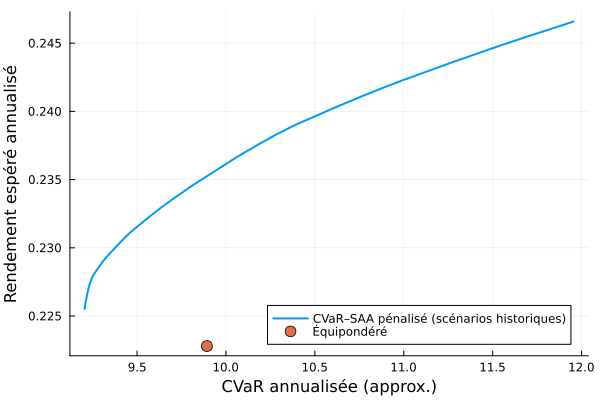

In [79]:
#### Cellule 2.15 ######

 #Tracé de la frontière CVaR :
 #relation entre le risque extrême (CVaR) et le rendement espéré
p1 = plot(results_cvar.CVaR_ann, results_cvar.ER_ann,
    xlabel="CVaR annualisée (approx.)",
    ylabel="Rendement espéré annualisé",
    label="CVaR–SAA pénalisé (scénarios historiques)",
    legend=:bottomright,
    linewidth=2
)

# Ajout du portefeuille équipondéré (benchmark)
scatter!(p1, [CVaR_EW_ann], [ER_EW_ann],
         label="Équipondéré",
         markersize=6)

# Sauvegarde de la figure
savefig(p1, joinpath(OUTDIR, "chap2_sec2_4_fig1_ER_vs_CVaR.png"))

# Affichage
p1

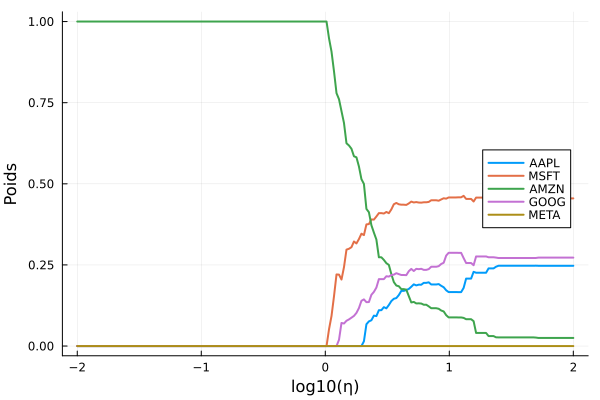

In [87]:
####### Cellule 2.16 ########

 #Tracé de l’évolution des poids optimaux en fonction de log10(η)
#Permet d’analyser comment la composition du portefeuille varie
 #avec le niveau d’aversion au risque (CVaR)
pW = plot(
    xlabel="log10(η)",
    ylabel="Poids",
    legend=:right
)

#Ajout des courbes pour chaque actif
for j in 1:N
    plot!(pW,
          results_cvar.log10η,
          X_cvar[:, j],
          label=TICKERS[j],
          linewidth=2)
end

#Sauvegarde de la figure
savefig(pW, joinpath(OUTDIR, "chap2_sec2_4_fig2_weights_vs_eta.png"))

# Affichage
pW

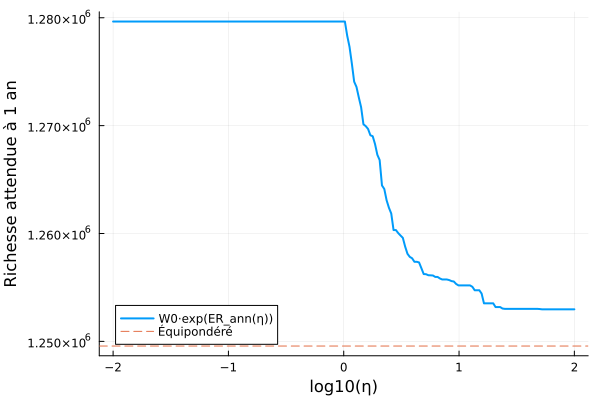

In [89]:
##### Cellule 2.17 ######

   #Tracé de la richesse attendue à 1 an en fonction de log10(η)
#Cela permet d’évaluer l’effet du paramètre de pénalisation
 # sur la richesse future du portefeuille optimal
pR = plot(results_cvar.log10η, results_cvar.EW1,
    xlabel="log10(η)",
    ylabel="Richesse attendue à 1 an",
    label="W0·exp(ER_ann(η))",
    legend=:bottomleft,
    linewidth=2
)

   # Ajout d’une ligne horizontale correspondant
    #au portefeuille équipondéré
hline!(pR, [EW1_EW],
       label="Équipondéré",
       linestyle=:dash)

  #Sauvegarde de la figure
savefig(pR, joinpath(OUTDIR, "chap2_sec2_4_fig3_wealth_vs_eta.png"))

#Affichage
pR

In [93]:
 ###Cellule 2.18 #######

  #Choix d’une valeur spécifique du paramètre η
   #pour analyser un portefeuille optimal particulier
η0= 1.0

#Recherche de l’indice correspondant dans les résultats
  idx0= argmin(abs.(results_cvar.η .- η0))

  #Extraction des poids optimaux et des métriques associées

    x0= X_cvar[idx0, :]
    row0= results_cvar[idx0, :]

#Construction d’un tableau comparatif :
#portefeuille optimisé vs portefeuille équipondéré
baseline = DataFrame(
    Portefeuille = ["Optimisé (η=$(η0))", "Équipondéré"],
    ER_ann= [row0.ER_ann, ER_EW_ann],   # rendement espéré
    CVaR_ann = [row0.CVaR_ann, CVaR_EW_ann],   # risque extrême
    EW1 = [row0.EW1, EW1_EW]   # richesse attendue
)

# Affichage
baseline

Row,Portefeuille,ER_ann,CVaR_ann,EW1
,String,Float64,Float64,Float64
1,Optimisé (η=1.0),0.246585,11.9546,1.27965e6
2,Équipondéré,0.222798,9.89305,1.24957e6


Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
η_plot = 1.0
Indice CVaR choisi (grille) = 100 | η ≈ 0.9771241535346498
Poids MV   = [0.18944253501156513, 0.34439741671470303, 0.2654060329076043, 0.20075401518525027, 1.8087709370455232e-10]
Poids CVaR = [0.0, 0.0, 1.0, 0.0, 0.0]
Poids EW   = [0.2, 0.2, 0.2, 0.2, 0.2]
Richesse finale : EW = 11.525772392666036 | MV = 12.569324634967579 | CVaR = 14.963049397121784


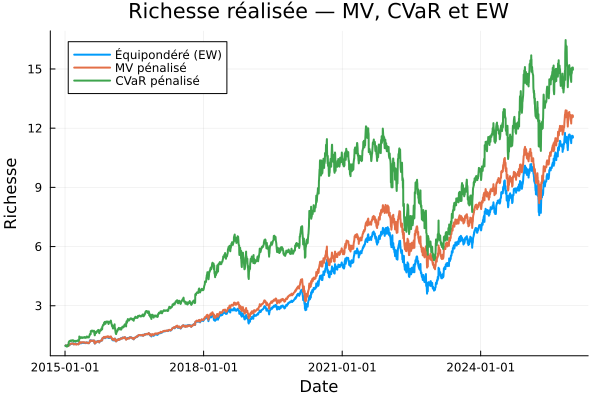

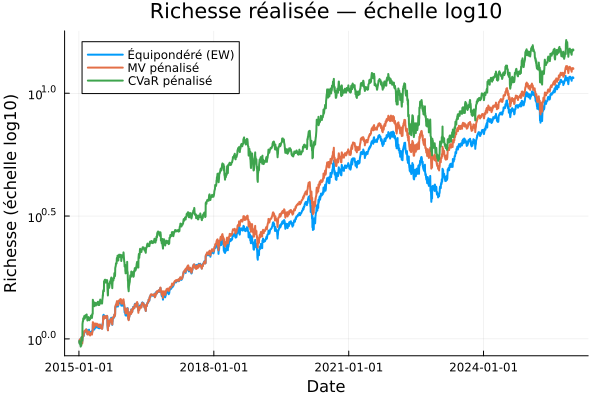

In [95]:
##### Cellule 2.19 #########

begin
    #Choix du paramètre η pour comparer MV et CVaR
    η_plot= 1.0

     #Fonction utilitaire : indice de la valeur la plus proche
    nearest_index(v::AbstractVector{<:Real}, a::Real) = argmin(abs.(v .- a))

    # Vérification de l’existence des résultats CVaR déjà calculés
    if !(@isdefined(results_cvar))
        println("results_cvar n'existe pas. Exécute d'abord la résolution CVaR sur la grille.")
        return nothing
    end

    if !(@isdefined(X_cvar))
        println("Matrice des poids CVaR introuvable : il faut X_cvar.")
        return nothing
    end

      #Récupération des poids CVaR correspondant à η_plot
    idx_cvar = nearest_index(results_cvar.η, η_plot)
    x_cvar = vec(X_cvar[idx_cvar, :])

    #Paramètres statistiques pour recalculer le portefeuille MV
    μ_daily_mv = vec(mean(R_log, dims=1))
    Σ_daily_mv= cov(R_log, corrected=true)

    μ_ann_mv= FREQ .* μ_daily_mv
    Σ_ann_mv = FREQ .* Σ_daily_mv

    #Résolution du problème moyenne-variance pénalisé
    function solve_mv_penalized(μ::Vector{Float64}, Σ::Matrix{Float64}, η::Float64)
        N= length(μ)

        model = Model(Gurobi.Optimizer)
        set_silent(model)

        @variable(model, x[1:N] >= 0)
        @constraint(model, sum(x) == 1.0)

        @objective(
            model,
            Min,
            η * sum(Σ[i, j] * x[i] * x[j] for i in 1:N, j in 1:N) - sum(μ[i] * x[i] for i in 1:N)
        )

        optimize!(model)

        return value.(x)
    end

     #Poids du portefeuille MV pour la même valeur de η
    x_mv= solve_mv_penalized(Vector{Float64}(μ_ann_mv), Matrix{Float64}(Σ_ann_mv), η_plot)

      #Fonction de richesse réalisée à partir des log-rendements cumulés
    # W_t = W0 * exp(sum_{s<=t} r_s^p)
    W0_plot= 1.0
    wealth_path_log(rp::AbstractVector{<:Real}; W0::Real = 1.0) = W0 .* exp.(cumsum(rp))

    # Rendements de portefeuille
    rp_MV= R_log * x_mv
    rp_CVaR = R_log * x_cvar
    rp_EW = R_log * xEW

    #Trajectoires de richesse
    W_MV = wealth_path_log(rp_MV; W0 = W0_plot)
     W_CVaR = wealth_path_log(rp_CVaR; W0 = W0_plot)
    W_EW  = wealth_path_log(rp_EW; W0 = W0_plot)

      #Affichage des principales informations
    println("η_plot = ", η_plot)
    println("Indice CVaR choisi (grille) = ", idx_cvar, " | η ≈ ", results_cvar.η[idx_cvar])
    println("Poids MV   = ", x_mv)
    println("Poids CVaR = ", x_cvar)
    println("Poids EW   = ", xEW)
    println("Richesse finale : EW = ", W_EW[end], " | MV = ", W_MV[end], " | CVaR = ", W_CVaR[end])

    # Figure 1: richesse réalisée en niveau
    p1 = plot(
        dates_ret, W_EW,
        label = "Équipondéré (EW)",
        lw = 2,
        xlabel = "Date",
        ylabel = "Richesse",
        title = "Richesse réalisée — MV, CVaR et EW"
    )
    plot!(p1, dates_ret, W_MV, label = "MV pénalisé", lw = 2)
    plot!(p1, dates_ret, W_CVaR, label = "CVaR pénalisé", lw = 2)
    display(p1)

     #Figure 2:richesse réalisée en échelle logarithmique
    p2 = plot(
        dates_ret, W_EW,
        label = "Équipondéré (EW)",
        lw = 2,
        yscale = :log10,
        xlabel = "Date",
        ylabel = "Richesse (échelle log10)",
        title = "Richesse réalisée — échelle log10"
    )
    plot!(p2, dates_ret, W_MV, label = "MV pénalisé", lw = 2)
    plot!(p2, dates_ret, W_CVaR, label = "CVaR pénalisé", lw = 2)
    display(p2)

    # Sauvegarde des figures
    savefig(p1, joinpath(OUTDIR, "chap2_sec2_4_fig_wealth_path.png"))
    savefig(p2, joinpath(OUTDIR, "chap2_sec2_4_fig_wealth_path_log10.png"))

    nothing
end